<a href="https://colab.research.google.com/github/overgroove/samsung_lecture/blob/main/05_feature_eng_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Feature selection**
- feature engineering중 가장 중요한 단계 중 하나
- 변수의 전처리 과정 중 생성 된 다양한 파생변수에 따라 변수 갯수가 많아진 상황
- 타겟데이터에 유용한 변수만을 선택해준다면 데이터의 노이즈를 줄이고 오버피팅문제를 해결 할 수 있어 모델 퍼포먼스를 끌어올리는데 효과적

## **data loading**

In [9]:
# 필요모듈 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

pd.options.display.max_columns = 300
pd.options.display.max_rows = 300

In [4]:
# ames_transform 데이터 로딩
data = joblib.load('./final_data.joblib')
data.keys()

dict_keys(['X_train', 'X_test', 'y_train', 'y_test'])

In [6]:
# 학습데이터 분리
X_train, X_test, y_train, y_test = data['X_train'], data['X_test'], data['y_train'], data['y_test']

In [10]:
X_train.head()

,num_high_skew_log_scaled__MSSubClass,num_high_skew_log_scaled__LotFrontage,num_high_skew_log_scaled__LotArea,num_high_skew_log_scaled__MasVnrArea,num_high_skew_log_scaled__BsmtFinSF1,num_high_skew_log_scaled__BsmtFinSF2,num_high_skew_log_scaled__TotalBsmtSF,num_high_skew_log_scaled__1stFlrSF,num_high_skew_log_scaled__LowQualFinSF,num_high_skew_log_scaled__GrLivArea,num_high_skew_log_scaled__BsmtHalfBath,num_high_skew_log_scaled__KitchenAbvGr,num_high_skew_log_scaled__WoodDeckSF,num_high_skew_log_scaled__OpenPorchSF,num_high_skew_log_scaled__EnclosedPorch,num_high_skew_log_scaled__3SsnPorch,num_high_skew_log_scaled__ScreenPorch,num_high_skew_log_scaled__PoolArea,num_high_skew_log_scaled__MiscVal,num_low_skew_scaled__Id,num_low_skew_scaled__OverallQual,num_low_skew_scaled__OverallCond,num_low_skew_scaled__YearBuilt,num_low_skew_scaled__YearRemodAdd,num_low_skew_scaled__BsmtUnfSF,num_low_skew_scaled__2ndFlrSF,num_low_skew_scaled__BsmtFullBath,num_low_skew_scaled__FullBath,num_low_skew_scaled__HalfBath,num_low_skew_scaled__BedroomAbvGr,num_low_skew_scaled__TotRmsAbvGrd,num_low_skew_scaled__Fireplaces,num_low_skew_scaled__GarageYrBlt,num_low_skew_scaled__GarageCars,num_low_skew_scaled__GarageArea,num_low_skew_scaled__MoSold,num_low_skew_scaled__YrSold,cat_high_card_target_encoded__0,cat_low_card_onehot_encoded__MSZoning_'C (all)',cat_low_card_onehot_encoded__MSZoning_FV,cat_low_card_onehot_encoded__MSZoning_RH,cat_low_card_onehot_encoded__MSZoning_RL,cat_low_card_onehot_encoded__MSZoning_RM,cat_low_card_onehot_encoded__Street_Grvl,cat_low_card_onehot_encoded__Street_Pave,cat_low_card_onehot_encoded__Alley_Grvl,cat_low_card_onehot_encoded__Alley_Pave,cat_low_card_onehot_encoded__LotShape_IR1,cat_low_card_onehot_encoded__LotShape_IR2,cat_low_card_onehot_encoded__LotShape_IR3,cat_low_card_onehot_encoded__LotShape_Reg,cat_low_card_onehot_encoded__LandContour_Bnk,cat_low_card_onehot_encoded__LandContour_HLS,cat_low_card_onehot_encoded__LandContour_Low,cat_low_card_onehot_encoded__LandContour_Lvl,cat_low_card_onehot_encoded__Utilities_AllPub,cat_low_card_onehot_encoded__Utilities_NoSeWa,cat_low_card_onehot_encoded__LotConfig_Corner,cat_low_card_onehot_encoded__LotConfig_CulDSac,cat_low_card_onehot_encoded__LotConfig_FR2,cat_low_card_onehot_encoded__LotConfig_FR3,cat_low_card_onehot_encoded__LotConfig_Inside,cat_low_card_onehot_encoded__LandSlope_Gtl,cat_low_card_onehot_encoded__LandSlope_Mod,cat_low_card_onehot_encoded__LandSlope_Sev,cat_low_card_onehot_encoded__Condition1_Artery,cat_low_card_onehot_encoded__Condition1_Feedr,cat_low_card_onehot_encoded__Condition1_Norm,cat_low_card_onehot_encoded__Condition1_PosA,cat_low_card_onehot_encoded__Condition1_PosN,cat_low_card_onehot_encoded__Condition1_RRAe,cat_low_card_onehot_encoded__Condition1_RRAn,cat_low_card_onehot_encoded__Condition1_RRNe,cat_low_card_onehot_encoded__Condition1_RRNn,cat_low_card_onehot_encoded__Condition2_Artery,cat_low_card_onehot_encoded__Condition2_Feedr,cat_low_card_onehot_encoded__Condition2_Norm,cat_low_card_onehot_encoded__Condition2_PosN,cat_low_card_onehot_encoded__Condition2_RRAe,cat_low_card_onehot_encoded__Condition2_RRAn,cat_low_card_onehot_encoded__BldgType_1Fam,cat_low_card_onehot_encoded__BldgType_2fmCon,cat_low_card_onehot_encoded__BldgType_Duplex,cat_low_card_onehot_encoded__BldgType_Twnhs,cat_low_card_onehot_encoded__BldgType_TwnhsE,cat_low_card_onehot_encoded__HouseStyle_1.5Fin,cat_low_card_onehot_encoded__HouseStyle_1.5Unf,cat_low_card_onehot_encoded__HouseStyle_1Story,cat_low_card_onehot_encoded__HouseStyle_2.5Fin,cat_low_card_onehot_encoded__HouseStyle_2.5Unf,cat_low_card_onehot_encoded__HouseStyle_2Story,cat_low_card_onehot_encoded__HouseStyle_SFoyer,cat_low_card_onehot_encoded__HouseStyle_SLvl,cat_low_card_onehot_encoded__RoofStyle_Flat,cat_low_card_onehot_encoded__RoofStyle_Gable,cat_low_card_onehot_encoded__RoofStyle_Gambrel,cat_low_card_onehot_encoded__RoofStyle_Hip,cat_low_card_onehot_encoded__RoofStyle_Mansard,cat_low_card_onehot_encoded__

전처리 과정중에서 변수가 274개로 늘어난 상황  
통계적 방법보다는 머신러닝 모델을 활용한 변수 선택 방법을 사용

## **1. ML selection**
### **1.1 Lasso coef_활용**
- 선형모델 기반 변수 선택에 자주 사용하는 모델이 Lasso
- Lasso모델은 규제화 모델로 선형모델의 변수가 많아질경우 오버피팅 문제를 해결하기 위해 사용
- 계수값인 $\beta$ 절대값의 합을 비용함수에 추가
- 변수에 해당하는 계수값을 0으로 만들면서 학습
- 결국 모델 결과값에 영향을 주지 않는 변수를 삭제하는 효과를 가짐

### **Lasso 모델**
<div align="center">
  <img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/17.png" width="500">
</div>

**특징**  
- 기존 회귀모델의 비용함수에 설명변수의 베타 절대값의 합 $\lambda\sum_{j=1}^p\left\vert\beta_j\right\vert$를 패널티 식으로 추가.  
$$J = \sum_{i=1}^n{(y_i - \hat y_i)^2} + \lambda\sum_{j=1}^p\left\vert\beta_j\right\vert$$  
> $n$ : 샘플갯수  
> $p$ : 설명변수갯수  

**학습**
- 회귀모델의 오차와 베타 절대값합에 해당 하는 값(비용함수)을 동시에 최소화  
- 모델이 최적화 과정을 거치면서 비용함수의 최소값이 패널티 영역과 만나는 지점(마름모의 꼭지점)에서 정규화 모델의 최적이 이루어집니다.  
- 비용함수에 더해진 규제화텀의 영향으로 비용함수를 줄이는데 불필요하게 계상 된 $\beta$ 값을 0으로 만들면서 모델링을 합니다. (설명변수의 영향도 삭제)

**효과 및 활용**
- 모델링 과정에서 불필요한 설명변수를 **제거하는** 효과를 갖습니다.  
- 많은 변수를 사용하는 모델에 큰 패널티를 주며 독립변수의 갯수가 많거나 추정되는 $\beta$ 값이 비정상적으로 클 때 설명변수를 삭제하여 복잡도를 개선 overfitting 되는 문제를 해결하기 위해 활용합니다.

In [12]:
# 선형 회귀 모델
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8687079209119204

In [21]:
# Lasso import 및 fitting, score 확인
from sklearn.linear_model import Lasso
Lasso_model = Lasso(alpha=30) # alpha=1 규제화 강도 설정
Lasso_model.fit(X_train, y_train)
Lasso_model.score(X_test, y_test)

0.8789125388141611

In [ ]:
'''3
0.8729070303734814
7
0.8745404469288981
9
0.8768647752415984
10
0.8775275777011595
15
0.8783204820266879
30
0.8789125388141611
'''

In [24]:
# coef_ threashold 기준 변수 선별
X_train.loc[:, Lasso_model.coef_ != 0]

,num_high_skew_log_scaled__MSSubClass,num_high_skew_log_scaled__LotFrontage,num_high_skew_log_scaled__LotArea,num_high_skew_log_scaled__MasVnrArea,num_high_skew_log_scaled__BsmtFinSF1,num_high_skew_log_scaled__BsmtFinSF2,num_high_skew_log_scaled__TotalBsmtSF,num_high_skew_log_scaled__1stFlrSF,num_high_skew_log_scaled__LowQualFinSF,num_high_skew_log_scaled__GrLivArea,num_high_skew_log_scaled__BsmtHalfBath,num_high_skew_log_scaled__KitchenAbvGr,num_high_skew_log_scaled__WoodDeckSF,num_high_skew_log_scaled__OpenPorchSF,num_high_skew_log_scaled__EnclosedPorch,num_high_skew_log_scaled__3SsnPorch,num_high_skew_log_scaled__ScreenPorch,num_high_skew_log_scaled__PoolArea,num_high_skew_log_scaled__MiscVal,num_low_skew_scaled__Id,num_low_skew_scaled__OverallQual,num_low_skew_scaled__OverallCond,num_low_skew_scaled__YearBuilt,num_low_skew_scaled__YearRemodAdd,num_low_skew_scaled__BsmtUnfSF,num_low_skew_scaled__2ndFlrSF,num_low_skew_scaled__BsmtFullBath,num_low_skew_scaled__FullBath,num_low_skew_scaled__HalfBath,num_low_skew_scaled__BedroomAbvGr,num_low_skew_scaled__TotRmsAbvGrd,num_low_skew_scaled__Fireplaces,num_low_skew_scaled__GarageYrBlt,num_low_skew_scaled__GarageCars,num_low_skew_scaled__GarageArea,num_low_skew_scaled__MoSold,num_low_skew_scaled__YrSold,cat_high_card_target_encoded__0,cat_low_card_onehot_encoded__MSZoning_'C (all)',cat_low_card_onehot_encoded__MSZoning_FV,cat_low_card_onehot_encoded__MSZoning_RH,cat_low_card_onehot_encoded__MSZoning_RM,cat_low_card_onehot_encoded__Street_Grvl,cat_low_card_onehot_encoded__Street_Pave,cat_low_card_onehot_encoded__Alley_Grvl,cat_low_card_onehot_encoded__Alley_Pave,cat_low_card_onehot_encoded__LotShape_IR1,cat_low_card_onehot_encoded__LotShape_IR2,cat_low_card_onehot_encoded__LotShape_IR3,cat_low_card_onehot_encoded__LotShape_Reg,cat_low_card_onehot_encoded__LandContour_Bnk,cat_low_card_onehot_encoded__LandContour_HLS,cat_low_card_onehot_encoded__LandContour_Low,cat_low_card_onehot_encoded__LandContour_Lvl,cat_low_card_onehot_encoded__Utilities_AllPub,cat_low_card_onehot_encoded__Utilities_NoSeWa,cat_low_card_onehot_encoded__LotConfig_CulDSac,cat_low_card_onehot_encoded__LotConfig_FR2,cat_low_card_onehot_encoded__LotConfig_FR3,cat_low_card_onehot_encoded__LandSlope_Mod,cat_low_card_onehot_encoded__Condition1_Artery,cat_low_card_onehot_encoded__Condition1_Feedr,cat_low_card_onehot_encoded__Condition1_Norm,cat_low_card_onehot_encoded__Condition1_PosA,cat_low_card_onehot_encoded__Condition1_RRAe,cat_low_card_onehot_encoded__Condition1_RRAn,cat_low_card_onehot_encoded__Condition2_Artery,cat_low_card_onehot_encoded__Condition2_Feedr,cat_low_card_onehot_encoded__Condition2_PosN,cat_low_card_onehot_encoded__BldgType_1Fam,cat_low_card_onehot_encoded__BldgType_2fmCon,cat_low_card_onehot_encoded__BldgType_Twnhs,cat_low_card_onehot_encoded__BldgType_TwnhsE,cat_low_card_onehot_encoded__HouseStyle_1.5Fin,cat_low_card_onehot_encoded__HouseStyle_1.5Unf,cat_low_card_onehot_encoded__HouseStyle_1Story,cat_low_card_onehot_encoded__HouseStyle_2.5Unf,cat_low_card_onehot_encoded__HouseStyle_2Story,cat_low_card_onehot_encoded__HouseStyle_SLvl,cat_low_card_onehot_encoded__RoofStyle_Flat,cat_low_card_onehot_encoded__RoofStyle_Gable,cat_low_card_onehot_encoded__RoofStyle_Gambrel,cat_low_card_onehot_encoded__RoofStyle_Mansard,cat_low_card_onehot_encoded__RoofMatl_ClyTile,cat_low_card_onehot_encoded__RoofMatl_WdShngl,cat_low_card_onehot_encoded__Exterior1st_AsbShng,cat_low_card_onehot_encoded__Exterior1st_BrkFace,cat_low_card_onehot_encoded__Exterior1st_CemntBd,cat_low_card_onehot_encoded__Exterior1st_MetalSd,cat_low_card_onehot_encoded__Exterior1st_Stucco,cat_low_card_onehot_encoded__Exterior1st_VinylSd,cat_low_card_onehot_encoded__Exterior1st_WdShing,cat_low_card_onehot_encoded__Exterior2nd_'Wd Sdng',cat_low_card_onehot_encoded__Exterior2nd_'Wd Shng',cat_low_card_onehot_encoded__Exterior2nd_BrkFace,cat_low_card_onehot_encoded__Exterior2nd_CmentBd,cat_low_card_onehot_encoded__Exterior2nd_HdBoard,cat_low_card_oneh

### **1.2 treebase feature_importances_ 활용**
- DecisionTree 모델을 기반으로 한 ML모델에서 사용가능한 속성값
- 각 트리가 예측/분류 결과값을 내기 위해 트리의 분지에 사용한 변수에 해당 변수로 구분 된 데이터 갯수를 가중치로 normalized 된 값
- 결과를 내기 위해 모델이 중요하게 생각하는 변수의 우선순위

In [25]:
# treebase model feature importances_ 활용
# xgboost Re
from xgboost import XGBRegressor
xgbr = XGBRegressor(random_state=42)
xgbr.fit(X_train, y_train)
xgbr.score(X_test, y_test)

0.902634859085083

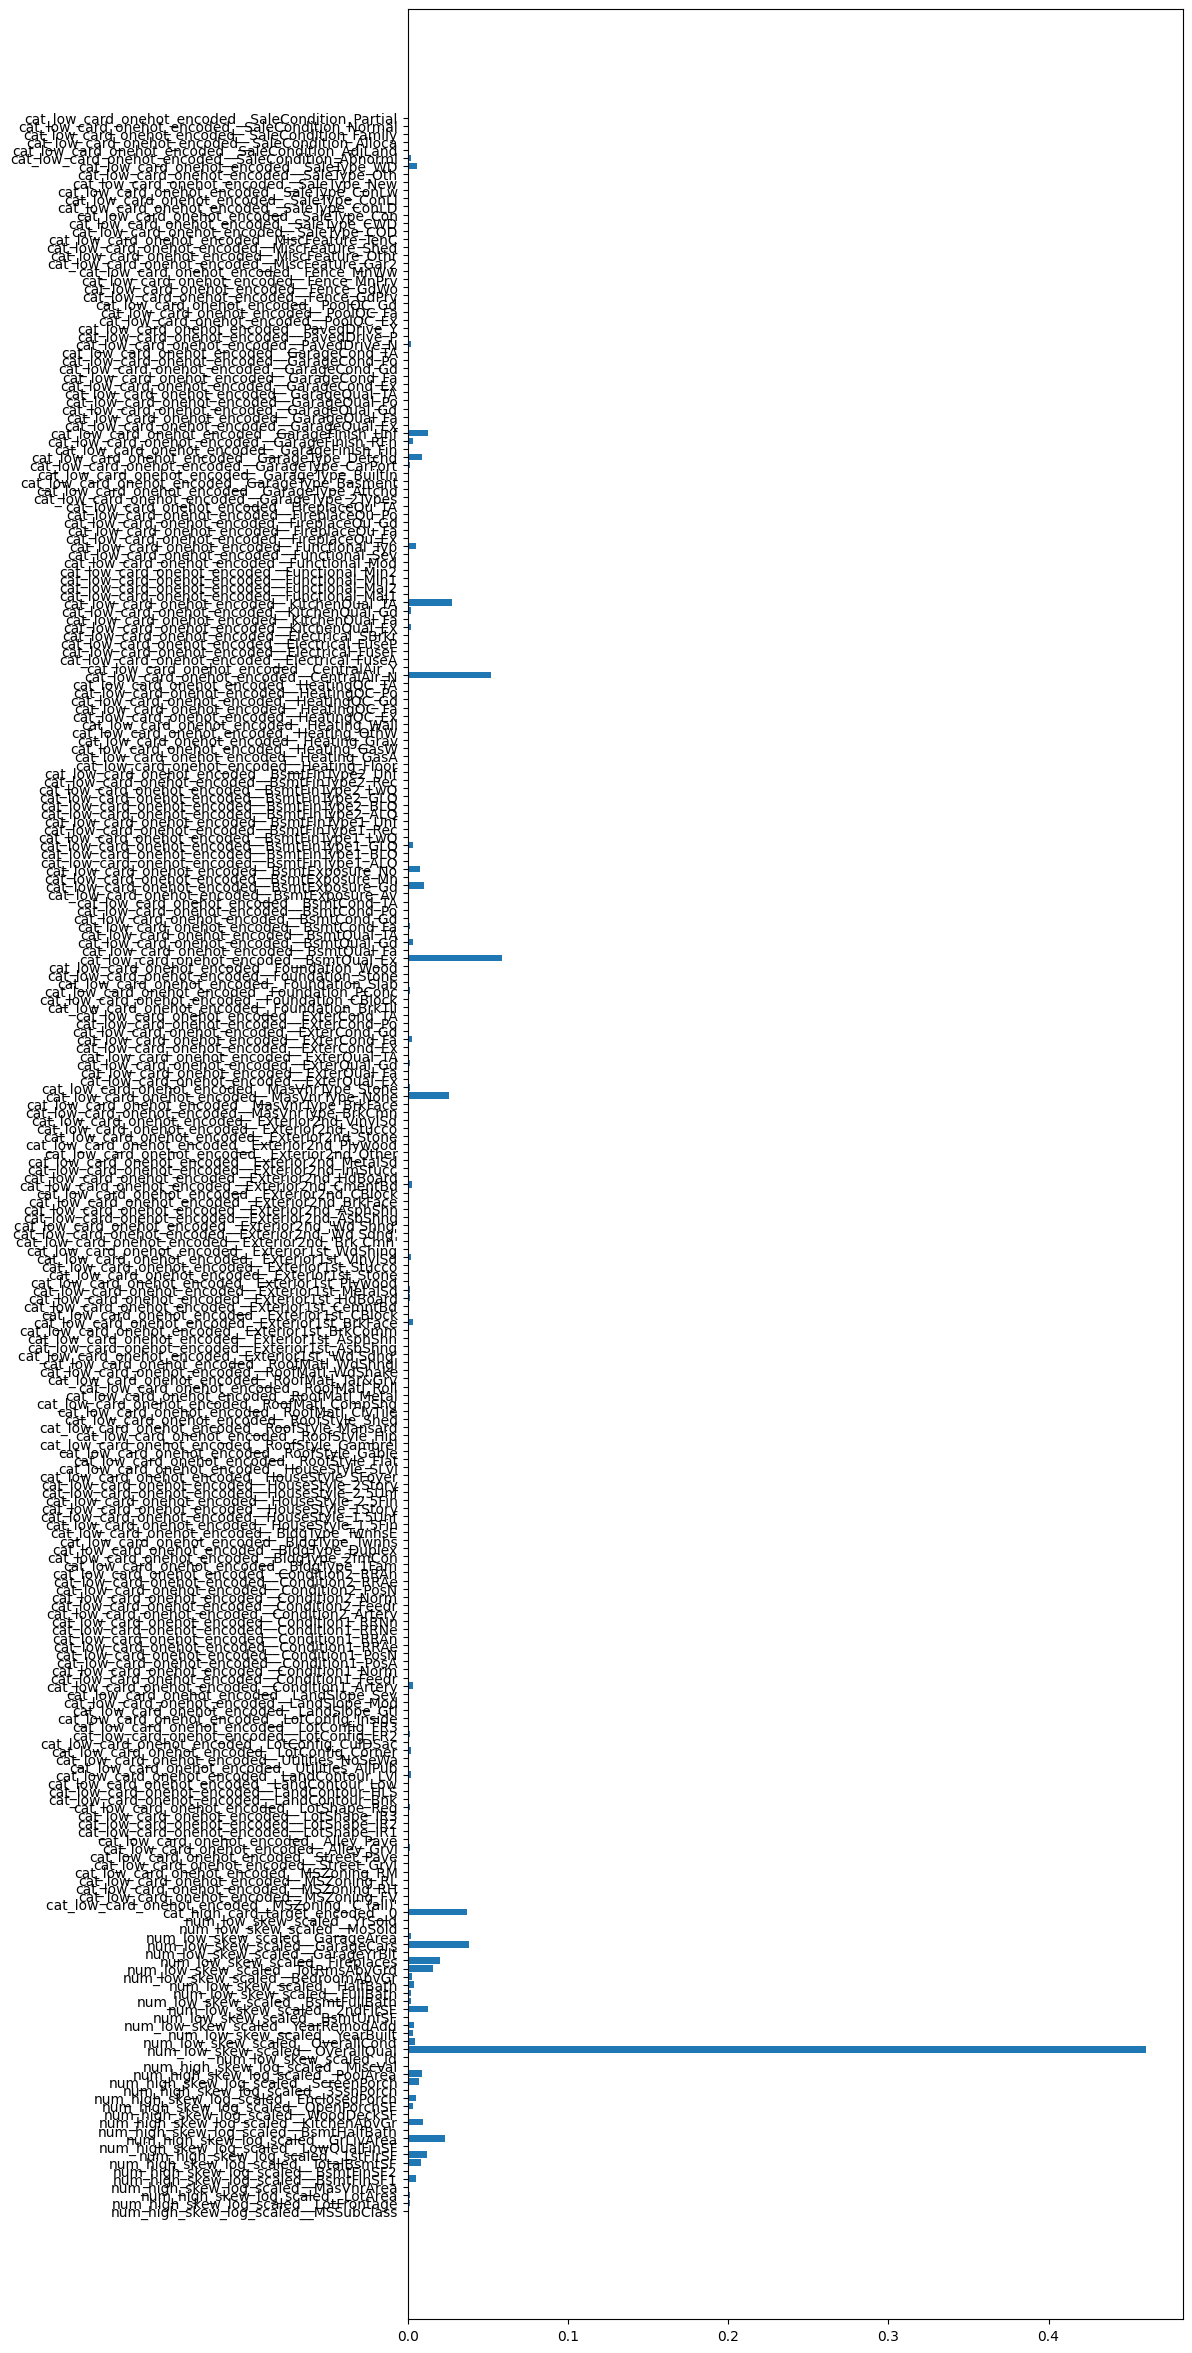

In [30]:
plt.figure(figsize=(10, 30))
plt.barh(X_train.columns, xgbr.feature_importances_)
plt.show()

In [34]:
xgbr.feature_importances_.shape, X_train.columns.shape

((260,), (260,))

In [37]:
df1 = pd.DataFrame(xgbr.feature_importances_, index=X_train.columns, columns=['coef']).sort_values('coef', ascending=False)

In [41]:
X_train.loc[:, df1.head(60).index]

,num_low_skew_scaled__OverallQual,cat_low_card_onehot_encoded__BsmtQual_Ex,cat_low_card_onehot_encoded__CentralAir_N,num_low_skew_scaled__GarageCars,cat_high_card_target_encoded__0,cat_low_card_onehot_encoded__KitchenQual_TA,cat_low_card_onehot_encoded__MasVnrType_None,num_high_skew_log_scaled__GrLivArea,num_low_skew_scaled__Fireplaces,num_low_skew_scaled__TotRmsAbvGrd,num_low_skew_scaled__2ndFlrSF,cat_low_card_onehot_encoded__GarageFinish_Unf,num_high_skew_log_scaled__1stFlrSF,cat_low_card_onehot_encoded__BsmtExposure_Gd,num_high_skew_log_scaled__KitchenAbvGr,cat_low_card_onehot_encoded__GarageType_Detchd,num_high_skew_log_scaled__PoolArea,num_high_skew_log_scaled__TotalBsmtSF,cat_low_card_onehot_encoded__BsmtExposure_No,num_high_skew_log_scaled__ScreenPorch,cat_low_card_onehot_encoded__SaleType_WD,num_high_skew_log_scaled__EnclosedPorch,cat_low_card_onehot_encoded__Functional_Typ,num_high_skew_log_scaled__BsmtFinSF1,num_low_skew_scaled__OverallCond,num_low_skew_scaled__YearRemodAdd,num_low_skew_scaled__HalfBath,cat_low_card_onehot_encoded__Exterior1st_BrkFace,cat_low_card_onehot_encoded__BsmtQual_Gd,num_low_skew_scaled__YearBuilt,cat_low_card_onehot_encoded__Condition1_Artery,cat_low_card_onehot_encoded__GarageFinish_RFn,cat_low_card_onehot_encoded__BsmtFinType1_GLQ,num_high_skew_log_scaled__OpenPorchSF,cat_low_card_onehot_encoded__Exterior2nd_CmentBd,num_low_skew_scaled__BedroomAbvGr,cat_low_card_onehot_encoded__ExterCond_Fa,num_low_skew_scaled__GarageArea,cat_low_card_onehot_encoded__PavedDrive_N,num_low_skew_scaled__BsmtFullBath,cat_low_card_onehot_encoded__LotConfig_Corner,cat_low_card_onehot_encoded__KitchenQual_Ex,cat_low_card_onehot_encoded__LandContour_Lvl,cat_low_card_onehot_encoded__Exterior1st_VinylSd,cat_low_card_onehot_encoded__SaleCondition_Abnorml,cat_low_card_onehot_encoded__KitchenQual_Gd,num_low_skew_scaled__FullBath,cat_low_card_onehot_encoded__Exterior1st_MetalSd,cat_low_card_onehot_encoded__Exterior1st_HdBoard,cat_low_card_onehot_encoded__Alley_Grvl,cat_low_card_onehot_encoded__BsmtCond_Fa,num_high_skew_log_scaled__LotArea,cat_low_card_onehot_encoded__Foundation_PConc,cat_low_card_onehot_encoded__MasVnrType_Stone,cat_low_card_onehot_encoded__ExterQual_Gd,cat_low_card_onehot_encoded__LotConfig_FR2,num_high_skew_log_scaled__LotFrontage,cat_low_card_onehot_encoded__GarageType_CarPort,cat_low_card_onehot_encoded__LotShape_Reg,cat_low_card_onehot_encoded__HeatingQC_Gd
135,0.636031,0.0,0.0,0.296063,189172.955120,1.0,0.0,0.453551,0.594240,0.279234,-0.802294,1.0,1.301065,0.0,-0.204665,0.0,-0.070097,0.368189,1.0,-0.301979,1.0,-0.39166,1.0,-1.420419,0.392266,-0.711644,-0.758517,0.0,0.0,-0.032378,0.0,0.0,0.0,-1.100078,0.0,0.135175,0.0,0.253813,0.0,-0.814295,0.0,0.0,1.0,0.0,0.0,0.0,0.767840,0.0,0.0,1.0,0.0,0.247419,1.0,0.0,0.0,0.0,0.546941,0.0,1.0,1.0
1452,-0.823057,0.0,0.0,0.296063,129636.122076,1.0,0.0,-0.904483,-0.943262,-0.948194,-0.802294,0.0,-0.114095,1.0,-0.204665,0.0,-0.070097,-0.387725,0.0,-0.301979,1.0,-0.39166,1.0,0.689403,-0.508624,0.976164,-0.758517,0.0,1.0,1.106434,0.0,0.0,1.0,0.456197,0.0,-1.098297,0.0,0.229814,0.0,1.112115,0.0,0.0,1.0,1.0,0.0,0.0,-1.069941,0.0,0.0,1.0,0.0,-1.723115,1.0,0.0,0.0,0.0,-1.991834,0.0,1.0,1.0
762,0.636031,0.0,0.0,0.296063,223063.595024,0.0,1.0,0.201283,-0.943262,0.279234,0.973582,1.0,-1.177818,0.0,-0.204665,0.0,-0.070097,-0.106255,0.0,-0.301979,0.0,-0.39166,1.0,-0.343515,-0.508624,1.169056,1.265515,0.0,1.0,1.236584,0.0,0.0,1.0,0.669419,0.0,0.135175,0.0,0.656997,0.0,-0.814295,0.0,0.0,1.0,1.0,0.0,1.0,0.767840,0.0,0.0,1.0,0.0,-0.103809,1.0,0.0,0.0,0.0,0.221381,0.0,1.0,0.0
932,2.095118,1.0,0.0,1.665189,223063.595024,0.0,0.0,0.828959,0.594240,0.892948,-0.802294,0.0,1.692265,0.0,-0.204665,0.0,-0.070097,0.698197,1.0,-0.301979,1.0,-0.39166,1.0,-1.420419,-0.508624,1.024387,-0.758517,0.0,0.0,1.138972,0.0,0.0,0.0,1.329798,0.0,0.135175,0.0,1.492165,0.0,-0.814295,1.0,1.0,1.0,1.0,0.0,0.0,0.767840,0.0,0.0,1.0,0.0,0.465688,1.0,1.0,0.0,0.0,0.697847,0.0,0.0,0.0
435,0.636031,0.0,0.0,0.296063,

### **1.3 permutation_importance(치환중요도)활용**
- 특정 변수의 샘플값을 무작위로 섞었을 때 모델의 성능이 얼만큼 감소하는지를 기준으로 변수의 중요도를 판단하는 기법
- 학습 된 모델에 테스트데이터 전달하여 기준점수(평가지표 스코어)측정
- 특정 변수값(샘플)을 무작위로 셔플하여 데이터에 노이즈 추가, 이 작업을 통해 타겟데이터와 해당 변수와의 관계가 완전히 파괴
- 뒤섞인 데이터를 모델에 전달하여 평가지표 재측정
- (원래점수 - 뒤섞인데이터 점수)가 높으면 높을수록 해당 변수에 의존하고 있다는 의미로 높은 중요도로 판단한다.

In [42]:
# sklearn.inspection permutation_importance
from sklearn.inspection import permutation_importance

In [43]:
# 컴퓨터 코어 갯수
import os
os.cpu_count()

2

In [44]:
%%time
# 셀 실행속도 측정
# 모델 생성 및 학습
result = permutation_importance(xgbr, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
# 필수 파라메터 어떤 모델(학습이 완료 된), X_test, y_test, 반복횟수, random_state

CPU times: user 1.81 s, sys: 184 ms, total: 1.99 s
Wall time: 57.8 s


In [49]:
# result 기준 변수 중요도 순으로 변수 정리
pd.DataFrame(result.importances_mean, index=X_test.columns, columns=['importance']).sort_values('importance', ascending=False)

,importance
num_low_skew_scaled__OverallQual,2.794360e-01
num_high_skew_log_scaled__GrLivArea,1.315712e-01
cat_high_card_target_encoded__0,3.814324e-02
num_high_skew_log_scaled__1stFlrSF,2.841023e-02
num_low_skew_scaled__2ndFlrSF,2.199613e-02
cat_low_card_onehot_encoded__BsmtQual_Ex,1.675474e-02
num_high_skew_log_scaled__TotalBsmtSF,1.578648e-02
num_high_skew_log_scaled__BsmtFinSF1,1.463909e-02
num_low_skew_scaled__TotRmsAbvGrd,1.419757e-02
num_low_skew_scaled__GarageCars,1.047635e-02


In [ ]:
# 중요도 기준 threshold 적용 변수 선택


,num_low_skew__OverallQual,num_high_skew__GrLivArea,num_high_skew__TotalBsmtSF,num_high_skew__1stFlrSF,num_high_skew__BsmtFinSF1,num_low_skew__GarageCars,num_high_skew__LotArea,num_low_skew__GarageArea,num_low_skew__TotRmsAbvGrd,num_low_skew__2ndFlrSF,num_low_skew__YearRemodAdd,num_low_skew__OverallCond,num_low_skew__YearBuilt,num_low_skew__Fireplaces,cat_high_card__Neighborhood_280000,num_high_skew__MasVnrArea,cat_low_card__GarageFinish_Unf,num_low_skew__FullBath,cat_low_card__CentralAir_Y
0,0.636031,0.453551,0.368189,1.301065,-1.420419,0.296063,0.247419,0.253813,0.279234,-0.802294,-0.711644,0.392266,-0.032378,0.594240,0.000000,1.303490,1.0,0.767840,1.0
1,-0.823057,-0.904483,-0.387725,-0.114095,0.689403,0.296063,-1.723115,0.229814,-0.948194,-0.802294,0.976164,-0.508624,1.106434,-0.943262,0.000000,0.821102,0.0,-1.069941,1.0
2,0.636031,0.201283,-0.106255,-1.177818,-0.343515,0.296063,-0.103809,0.656997,0.279234,0.973582,1.169056,-0.508624,1.236584,-0.943262,0.000000,-0.845461,1.0,0.767840,1.0
3,2.095118,0.828959,0.698197,1.692265,-1.420419,1.665189,0.465688,1.492165,0.892948,-0.802294,1.024387,-0.508624,1.138972,0.594240,0.000000,1.321431,0.0,0.767840,1.0
4,0.636031,0.415668,-0.058123,-0.929013,0.572161,0.296063,0.295441,0.349809,-0.334480,1.089252,0.542156,0.392266,0.813597,0.594240,0.000000,-0.845461,0.0,0.767840,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,-0.823057,-0.949810,0.184570,-0.161329,0.835078,-1.073062,-0.208378,-0.811747,-0.334480,-0.802294,0.349263,0.392266,-0.422828,-0.943262,0.000000,-0.845461,0.0,-1.069941,1.0
1456,-2.282144,-0.658883,0.267828,0.141836,0.436075,-1.073062,-0.852266,-1.234131,-0.334480,-0.802294,0.976164,2.194045,-0.520441,-0.943262,0.000000,-0.845461,1.0,-1.069941,1.0
1457,0.636031,0.422921,-0.043009,-0.948056,-1.420419,0.296063,-0.220232,0.407407,0.279234,1.109665,1.072610,0.392266,1.171509,-0.943262,0.000000,0.918381,0.0,0.767840,1.0
1458,-0.093513,-0.574538,-0.193325,-1.525091,-1.420419,0.296063,0.573592,0.244213,0.279234,0.358943,0.735048,2.194045,-1.659253,-0.943262,0.000000,-0.845461,1.0,-1.069941,1.0


## 1.4 **SHAP value**
- **SHAP(SHapley Additive exPlanations)** 은 개별 데이터의 예측값에 대해 각 피처가 어떤 영향을 주었는지 수학적으로 계산하는 기법.
- 단순히 "어떤 피처가 중요한가"를 넘어, 그 피처가 예측값을 얼마나(+/-) 변화시켰는지를 설명
- SHAP은 게임 이론의 Shapley Value를 머신러닝에 이식  
여러 명의 선수(피처)가 팀(모델)을 이뤄 점수(예측값)를 냈을 때, 각 선수의 공헌도를 공정하게 배분하는 방식입니다.

$$f(x) = BaseValue + \sum_{i=1}^{M} \phi_i$$

> BaseValue ($E[f(X)]$): 모델에 아무런 정보를 주지 않았을 때의 평균 예측값입니다.  
> SHAP Value ($\phi_i$): 특정 피처 $i$가 추가됨으로써 베이스라인 대비 예측값이 변한 정도  
> Final Prediction ($f(x)$): 모든 피처의 SHAP Value를 베이스라인에 더하면 최종 예측값이 됩니다.

- 딥러닝 모델에도 적용 가능하며 최근 머신러닝 및 딥러닝 프로젝트에는 필수적으로 사용하는 하는 요소입니다.
- 모델이 복잡해짐에 따라 변수와 변수간 관계 분석이 어려워짐으로 인해 모델 출력결과값을 기반으로 한 변수중요도를 파악합니다.

In [50]:
# 모듈 import
import shap

In [51]:
exp = shap.TreeExplainer(xgbr)

In [53]:
shap_value = exp.shap_values(X_test)
shap_value.shape

(438, 260)

In [54]:
X_test.shape

(438, 260)

### **1.4.1 summary plot**
- 변수에 따른 모델의 전체적인 경향성을 파악하는 목적으로 사용
- 피처 중요도와 영향력의 방향(Positive/Negative)을 동시에 확인 가능함.

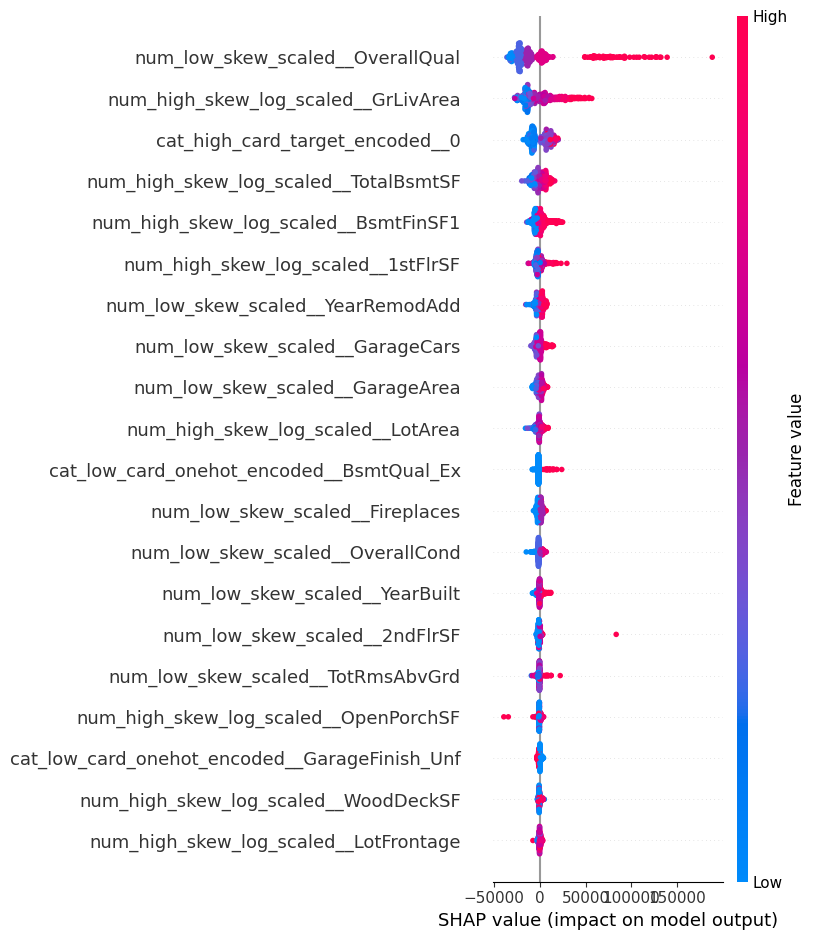

In [55]:
# summary plot
shap.summary_plot(shap_value, X_test)

### **1.4.1 shap value feature selection**
- 각 변수에 속한 샘플데이터의 shap value 평균값으로 변수 선별
- +/- 영향도를 모두 고려할 수 있도록 절대값 평균을 사용

In [60]:
# selection
pd.DataFrame(shap_value, columns=X_test.columns).abs().mean().sort_values(ascending=False)

,0
num_low_skew_scaled__OverallQual,26071.023438
num_high_skew_log_scaled__GrLivArea,14354.946289
cat_high_card_target_encoded__0,9197.561523
num_high_skew_log_scaled__TotalBsmtSF,5157.234375
num_high_skew_log_scaled__BsmtFinSF1,4441.438477
num_high_skew_log_scaled__1stFlrSF,3149.658691
num_low_skew_scaled__YearRemodAdd,2897.411865
num_low_skew_scaled__GarageCars,2854.416016
num_low_skew_scaled__GarageArea,2413.273926
num_high_skew_log_scaled__LotArea,2359.356689
